In [118]:
# pip install yfinance pandas numpy

import pandas as pd
import numpy as np
import yfinance as yf

In [119]:
# -----------------------------
# 1) Choose your 30 S&P 500 stocks
# -----------------------------
tickers = [
    "MSFT", "AAPL", "NVDA", "ADBE",
    "UNH", "ABBV", "ABT",
    "JPM", "BRK-B", "V", "BLK",
    "HON", "CAT", "LMT",
    "AMZN", "HD", "MCD",
    "GOOGL", "META", "NFLX",
    "PG", "KO",
    "XOM", "CVX",
    "NEE", "SO",
    "LIN", "APD",
    "PLD", "AMT"
]

In [120]:
# -----------------------------
# 2) Download 5 years of adjusted-close prices
# -----------------------------
prices = yf.download(
    tickers,
    period="10y",
    interval="1d",
    auto_adjust=False,
    progress=False
)["Adj Close"]

# Clean up
prices = prices.dropna(how="all").sort_index()


In [121]:
# -----------------------------
# 3) Compute daily log returns
# -----------------------------
log_returns = np.log(prices / prices.shift(1)).dropna()

In [122]:
# -----------------------------
# 4) Download VIX from FRED
# -----------------------------
vix_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=VIXCLS"
vix = pd.read_csv(vix_url)

# Clean column names
vix.columns = [str(c).strip().replace("\ufeff", "") for c in vix.columns]

print("VIX columns:", vix.columns.tolist())  # optional debug line

# Handle possible column name differences
date_col = None
vix_col = None

for c in vix.columns:
    cl = c.lower()
    if cl in ["date", "observation_date"]:
        date_col = c
    if cl in ["vixcls", "value"]:
        vix_col = c

if date_col is None or vix_col is None:
    raise ValueError(f"Unexpected VIX columns: {vix.columns.tolist()}")

vix[date_col] = pd.to_datetime(vix[date_col])
vix[vix_col] = pd.to_numeric(vix[vix_col], errors="coerce")

vix = (
    vix.rename(columns={date_col: "Date", vix_col: "VIX"})
       .set_index("Date")
       .dropna()
)

VIX columns: ['observation_date', 'VIXCLS']


In [123]:
def label_vix_regime(v):
    if v < 15:
        return "low"
    elif v < 25:
        return "normal"
    else:
        return "crisis"

vix["regime"] = vix["VIX"].apply(label_vix_regime)
regime_map = {"low": 0, "normal": 1, "crisis": 2}
vix["regime_code"] = vix["regime"].map(regime_map)

In [124]:
# -----------------------------
# 6) Merge returns with VIX/regimes
# -----------------------------
data = log_returns.join(vix[["VIX", "regime", "regime_code"]], how="inner")

In [125]:
# -----------------------------
# 7) 80/20 temporal split (no shuffling)
# -----------------------------
split_idx = int(len(data) * 0.8)

train_data = data.iloc[:split_idx].copy()
test_data  = data.iloc[split_idx:].copy()

# Separate pieces if helpful
X_train_returns = train_data[tickers]
X_test_returns  = test_data[tickers]

vix_train = train_data["VIX"]
vix_test  = test_data["VIX"]

regime_train = train_data["regime_code"]
regime_test  = test_data["regime_code"]


In [126]:
# -----------------------------
# 8) Quick checks
# -----------------------------
print("Prices shape:", prices.shape)
print("Returns shape:", log_returns.shape)
print("Merged data shape:", data.shape)
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)
print("\nRegime counts (train):")
print(train_data["regime"].value_counts())
print("\nRegime counts (test):")
print(test_data["regime"].value_counts())

print("\nHead of merged dataset:")
print(data.head())

Prices shape: (2513, 30)
Returns shape: (2512, 30)
Merged data shape: (2511, 33)
Train shape: (2008, 33)
Test shape: (503, 33)

Regime counts (train):
regime
normal    878
low       802
crisis    328
Name: count, dtype: int64

Regime counts (test):
regime
normal    352
low       123
crisis     28
Name: count, dtype: int64

Head of merged dataset:
                AAPL      ABBV       ABT      ADBE       AMT      AMZN  \
Date                                                                     
2016-03-21 -0.000094 -0.009948 -0.000736 -0.009897 -0.001693  0.003436   
2016-03-22  0.007619  0.026255  0.006602  0.000648 -0.004095  0.011665   
2016-03-23 -0.005544 -0.020025 -0.006112 -0.004331 -0.003508  0.016193   
2016-03-24 -0.004344 -0.004267 -0.000736  0.003899  0.007703  0.023114   
2016-03-28 -0.004553 -0.000179  0.003185 -0.001298 -0.001097 -0.005297   

                 APD       BLK     BRK-B       CAT  ...      NVDA        PG  \
Date                                                .

## Stress-Focused Evaluation Additions

The chronological 80/20 split is still the main holdout design, but the final test window can be relatively calm. These cells add diagnostics and stress-focused subsets so model performance can be evaluated on the full test set **and** on crisis/tail periods where downside-risk modeling matters most.


In [127]:
# -----------------------------
# Test-set stress diagnostics
# -----------------------------
print("Test regime counts:")
print(test_data["regime"].value_counts())
print("\nTest regime percentages:")
print((test_data["regime"].value_counts(normalize=True) * 100).round(2))

# Equal-weight portfolio return on the test set
test_ew_ret = test_data[tickers].mean(axis=1)

print("\nTest equal-weight return summary:")
print(test_ew_ret.describe(percentiles=[0.01, 0.05, 0.10, 0.90, 0.95, 0.99]).round(4))


Test regime counts:
regime
normal    352
low       123
crisis     28
Name: count, dtype: int64

Test regime percentages:
regime
normal    69.98
low       24.45
crisis     5.57
Name: proportion, dtype: float64

Test equal-weight return summary:
count    503.0000
mean       0.0004
std        0.0077
min       -0.0579
1%        -0.0216
5%        -0.0103
10%       -0.0079
50%        0.0008
90%        0.0084
95%        0.0102
99%        0.0154
max        0.0695
dtype: float64


In [128]:
# -----------------------------
# Stress-focused test subsets
# -----------------------------

# Work on a copy so we do not accidentally overwrite earlier objects
test_eval = test_data.copy()

# Equal-weight portfolio return on the full test set
test_eval["EW_portfolio_return"] = test_eval[tickers].mean(axis=1)

# Crisis-only subset based on your regime labels
test_crisis = test_eval[test_eval["regime"] == "crisis"].copy()

# High-VIX subset using the same crisis threshold logic
test_high_vix = test_eval[test_eval["VIX"] >= 25].copy()

# Worst 5% days in the test set
tail_5_threshold = test_eval["EW_portfolio_return"].quantile(0.05)
test_tail_5 = test_eval[test_eval["EW_portfolio_return"] <= tail_5_threshold].copy()

# Worst 1% days in the test set
tail_1_threshold = test_eval["EW_portfolio_return"].quantile(0.01)
test_tail_1 = test_eval[test_eval["EW_portfolio_return"] <= tail_1_threshold].copy()

print("Full test days:", len(test_eval))
print("Crisis test days:", len(test_crisis))
print("High-VIX test days:", len(test_high_vix))
print("Worst 5% test days:", len(test_tail_5))
print("Worst 1% test days:", len(test_tail_1))


Full test days: 503
Crisis test days: 28
High-VIX test days: 28
Worst 5% test days: 26
Worst 1% test days: 6


In [129]:
# -----------------------------
# Compare the stress level of each test subset
# -----------------------------
subset_summary = pd.DataFrame([
    {
        "subset": "full_test",
        "n_days": len(test_eval),
        "avg_abs_return": test_eval[tickers].abs().stack().mean(),
        "avg_std_across_assets": test_eval[tickers].std().mean(),
        "avg_VIX": test_eval["VIX"].mean(),
        "avg_EW_return": test_eval["EW_portfolio_return"].mean(),
        "worst_day": test_eval["EW_portfolio_return"].min()
    },
    {
        "subset": "crisis_only",
        "n_days": len(test_crisis),
        "avg_abs_return": test_crisis[tickers].abs().stack().mean(),
        "avg_std_across_assets": test_crisis[tickers].std().mean(),
        "avg_VIX": test_crisis["VIX"].mean(),
        "avg_EW_return": test_crisis["EW_portfolio_return"].mean(),
        "worst_day": test_crisis["EW_portfolio_return"].min()
    },
    {
        "subset": "high_vix",
        "n_days": len(test_high_vix),
        "avg_abs_return": test_high_vix[tickers].abs().stack().mean(),
        "avg_std_across_assets": test_high_vix[tickers].std().mean(),
        "avg_VIX": test_high_vix["VIX"].mean(),
        "avg_EW_return": test_high_vix["EW_portfolio_return"].mean(),
        "worst_day": test_high_vix["EW_portfolio_return"].min()
    },
    {
        "subset": "tail_5pct",
        "n_days": len(test_tail_5),
        "avg_abs_return": test_tail_5[tickers].abs().stack().mean(),
        "avg_std_across_assets": test_tail_5[tickers].std().mean(),
        "avg_VIX": test_tail_5["VIX"].mean(),
        "avg_EW_return": test_tail_5["EW_portfolio_return"].mean(),
        "worst_day": test_tail_5["EW_portfolio_return"].min()
    }
])

print(subset_summary.round(4))


        subset  n_days  avg_abs_return  avg_std_across_assets  avg_VIX  \
0    full_test     503          0.0115                 0.0164  17.8038   
1  crisis_only      28          0.0212                 0.0291  31.8582   
2     high_vix      28          0.0212                 0.0291  31.8582   
3    tail_5pct      26          0.0214                 0.0210  25.6512   

   avg_EW_return  worst_day  
0         0.0004    -0.0579  
1        -0.0053    -0.0579  
2        -0.0053    -0.0579  
3        -0.0173    -0.0579  


In [130]:
# -----------------------------
# Evaluation helpers for later model comparison
# -----------------------------
def summarize_portfolio_returns(port_ret, label="subset"):
    port_ret = pd.Series(port_ret).dropna()

    var_95 = port_ret.quantile(0.05)
    cvar_95 = port_ret[port_ret <= var_95].mean()

    return pd.Series({
        "subset": label,
        "n_days": len(port_ret),
        "mean": port_ret.mean(),
        "std": port_ret.std(),
        "min": port_ret.min(),
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })

def evaluate_by_subset(port_ret_series, subset_dict):
    port_ret_series = pd.Series(port_ret_series).dropna()
    results = []

    for subset_name, subset_df in subset_dict.items():
        aligned = port_ret_series.loc[subset_df.index].dropna()
        results.append(summarize_portfolio_returns(aligned, label=subset_name))

    return pd.DataFrame(results)

subset_dict = {
    "full_test": test_eval,
    "crisis_only": test_crisis,
    "high_vix": test_high_vix,
    "tail_5pct": test_tail_5,
    "tail_1pct": test_tail_1
}


In [131]:
# -----------------------------
# Example model comparison across stress-focused test subsets
# Run this cell after you create date-indexed portfolio-return series for each model
# -----------------------------
required_vars = ["gaussian_test_portfolio_returns", "flow_test_portfolio_returns"]
missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    print("Run this cell after creating the following date-indexed Series:")
    print(", ".join(missing_vars))
else:
    gaussian_results = evaluate_by_subset(gaussian_test_portfolio_returns, subset_dict)
    gaussian_results["approach"] = "Gaussian"

    flow_results = evaluate_by_subset(flow_test_portfolio_returns, subset_dict)
    flow_results["approach"] = "Flow"

    comparison = pd.concat([gaussian_results, flow_results], axis=0, ignore_index=True)
    comparison = comparison[["approach", "subset", "n_days", "mean", "std", "min", "VaR_95", "CVaR_95"]]

    print(comparison.round(4))


Run this cell after creating the following date-indexed Series:
gaussian_test_portfolio_returns, flow_test_portfolio_returns


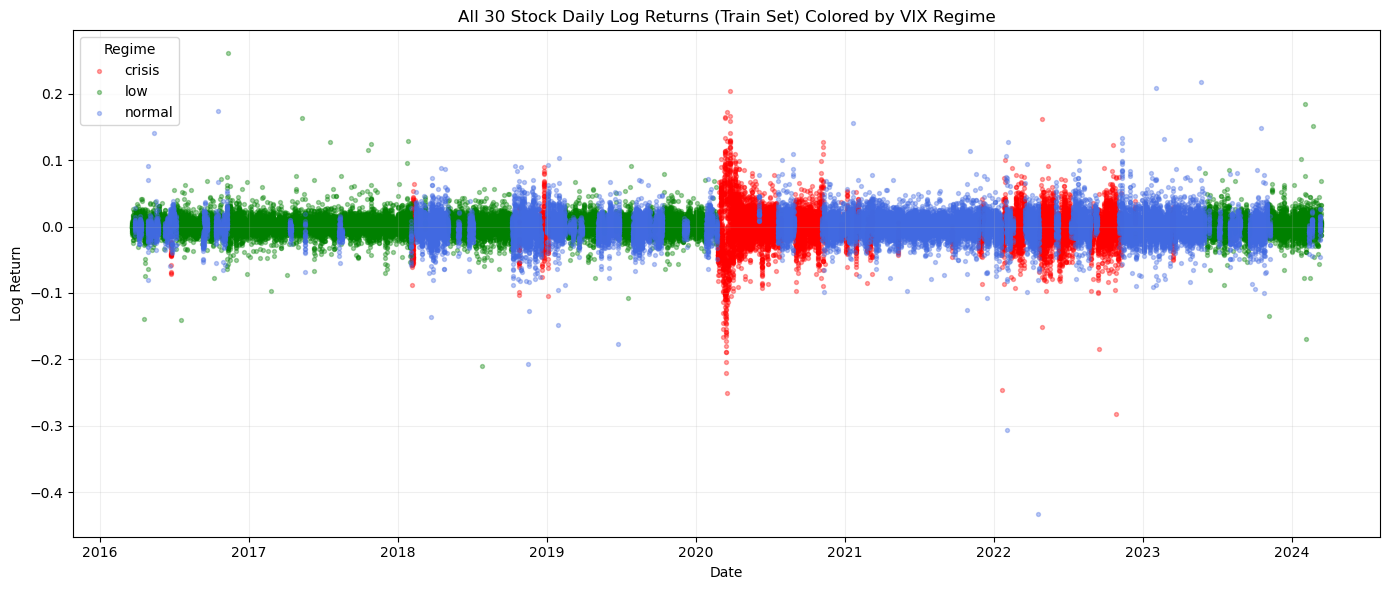

In [132]:
import matplotlib.pyplot as plt

# Long format: one row per (Date, Ticker, return)
returns_long = (
    X_train_returns.stack()
    .rename("return")
    .reset_index()
    .rename(columns={"level_1": "Ticker"})
)

# Add regime by date
returns_long["regime"] = returns_long["Date"].map(train_data["regime"])

# Color map for regimes
regime_colors = {"low": "green", "normal": "royalblue", "crisis": "red"}

plt.figure(figsize=(14, 6))
for r, grp in returns_long.groupby("regime"):
    plt.scatter(grp["Date"], grp["return"], s=8, alpha=0.35, c=regime_colors.get(r, "gray"), label=r)

plt.title("All 30 Stock Daily Log Returns (Train Set) Colored by VIX Regime")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend(title="Regime")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


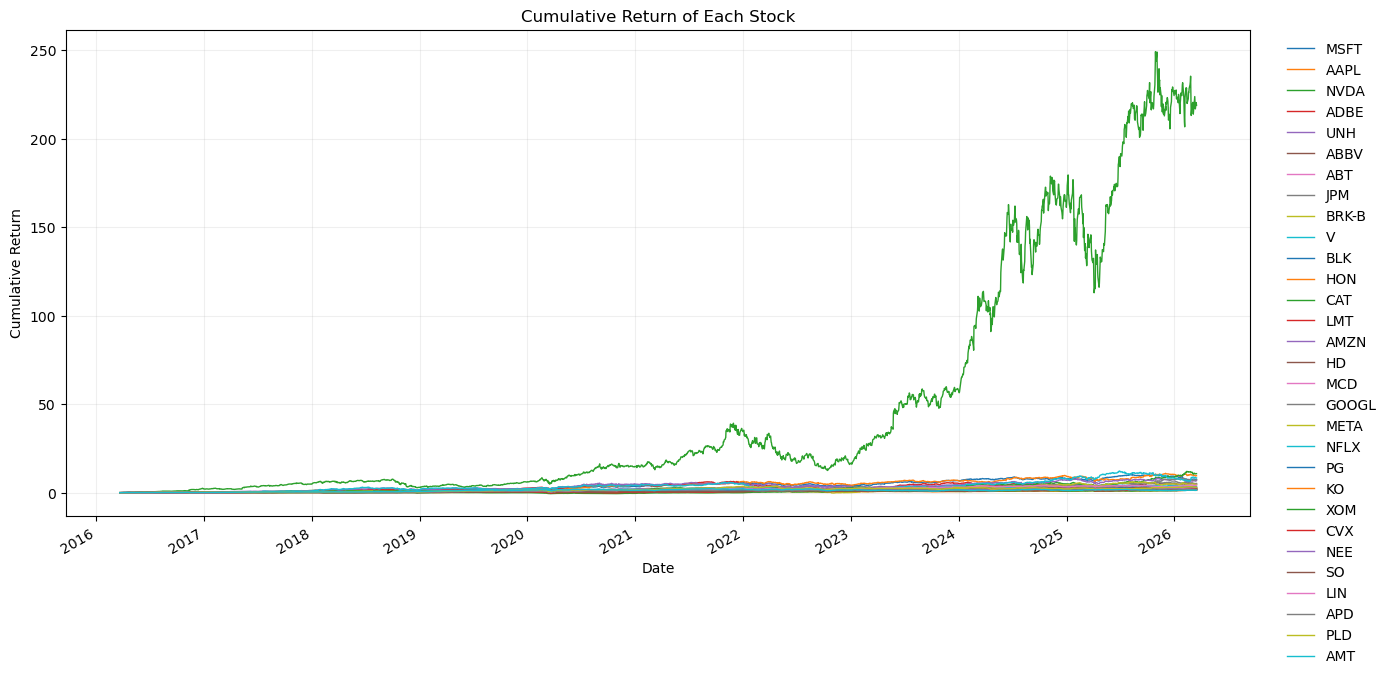

In [133]:
# Cumulative return from daily log returns: exp(cumsum(log_returns)) - 1
cum_returns = np.exp(log_returns[tickers].cumsum()) - 1

plt.figure(figsize=(14, 7))
cum_returns.plot(ax=plt.gca(), linewidth=1)
plt.title("Cumulative Return of Each Stock")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(alpha=0.2)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), ncol=1, frameon=False)
plt.tight_layout()
plt.show()

In [134]:
returns = data[tickers].copy()

print("Full data shape:", data.shape)
print("Returns shape:", returns.shape)
print("Date range:", data.index.min(), "to", data.index.max())
print("\nMissing values per column:")
print(data.isna().sum().sort_values(ascending=False).head(15))

split_idx = int(len(data) * 0.8)
print("\nTrain date range:", data.index[:split_idx].min(), "to", data.index[:split_idx].max())
print("Test date range:", data.index[split_idx:].min(), "to", data.index[split_idx:].max())

Full data shape: (2511, 33)
Returns shape: (2511, 30)
Date range: 2016-03-21 00:00:00 to 2026-03-16 00:00:00

Missing values per column:
AAPL      0
LMT       0
regime    0
VIX       0
XOM       0
V         0
UNH       0
SO        0
PLD       0
PG        0
NVDA      0
NFLX      0
NEE       0
MSFT      0
META      0
dtype: int64

Train date range: 2016-03-21 00:00:00 to 2024-03-12 00:00:00
Test date range: 2024-03-13 00:00:00 to 2026-03-16 00:00:00


Regime counts:
regime
crisis     356
low        925
normal    1230
Name: count, dtype: int64

Regime percentages:
regime
crisis    14.18
low       36.84
normal    48.98
Name: proportion, dtype: float64


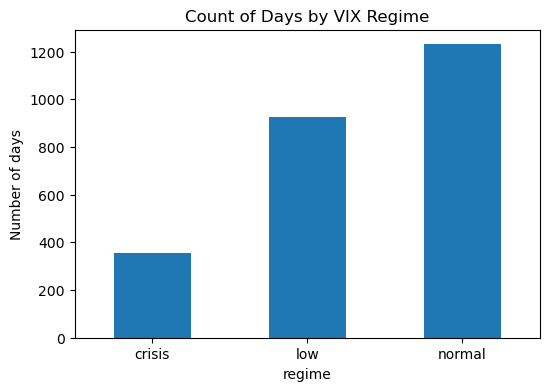

In [135]:
regime_counts = data["regime"].value_counts().sort_index()
regime_pct = data["regime"].value_counts(normalize=True).sort_index() * 100

print("Regime counts:")
print(regime_counts)
print("\nRegime percentages:")
print(regime_pct.round(2))

regime_counts.plot(kind="bar", figsize=(6,4), title="Count of Days by VIX Regime")
plt.ylabel("Number of days")
plt.xticks(rotation=0)
plt.show()

In [136]:
summary = pd.DataFrame({
    "mean": returns.mean(),
    "std": returns.std(),
    "skew": returns.skew(),
    "kurtosis": returns.kurtosis(),
    "min": returns.min(),
    "q01": returns.quantile(0.01),
    "q05": returns.quantile(0.05),
    "median": returns.median(),
    "q95": returns.quantile(0.95),
    "q99": returns.quantile(0.99),
    "max": returns.max()
}).sort_values("std", ascending=False)

print(summary.round(4))

         mean     std    skew  kurtosis     min     q01     q05  median  \
NVDA   0.0022  0.0312  0.0970    6.7105 -0.2077 -0.0797 -0.0464  0.0028   
NFLX   0.0009  0.0267 -1.7667   33.9715 -0.4326 -0.0668 -0.0365  0.0006   
META   0.0007  0.0244 -1.1926   25.7915 -0.3064 -0.0636 -0.0343  0.0010   
ADBE   0.0004  0.0214 -0.7777   10.1385 -0.1838 -0.0654 -0.0330  0.0012   
AMZN   0.0008  0.0204 -0.0162    5.1942 -0.1514 -0.0561 -0.0311  0.0012   
CAT    0.0010  0.0192 -0.2395    4.9426 -0.1541 -0.0530 -0.0289  0.0009   
UNH    0.0004  0.0191 -2.2366   31.6138 -0.2533 -0.0531 -0.0244  0.0008   
CVX    0.0004  0.0184 -1.1136   28.8911 -0.2501 -0.0462 -0.0259  0.0009   
AAPL   0.0009  0.0182 -0.0802    6.7907 -0.1377 -0.0494 -0.0282  0.0010   
GOOGL  0.0008  0.0181 -0.1904    4.6308 -0.1237 -0.0507 -0.0274  0.0013   
XOM    0.0004  0.0176 -0.2231    6.5477 -0.1304 -0.0493 -0.0263  0.0005   
BLK    0.0005  0.0174 -0.2090    8.9545 -0.1468 -0.0476 -0.0255  0.0009   
JPM    0.0007  0.0172 -0.

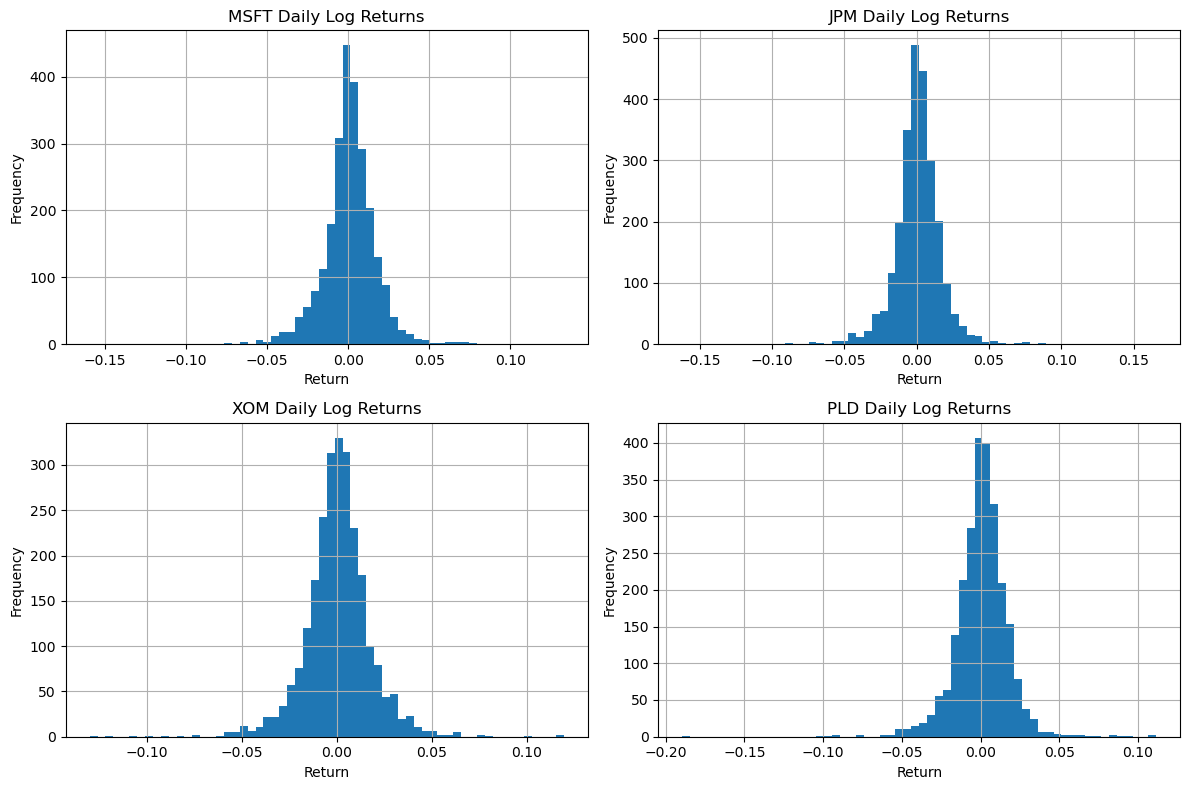

In [137]:
sample_stocks = ["MSFT", "JPM", "XOM", "PLD"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, stock in zip(axes, sample_stocks):
    returns[stock].hist(bins=60, ax=ax)
    ax.set_title(f"{stock} Daily Log Returns")
    ax.set_xlabel("Return")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [138]:
regime_stats = []

for r in ["low", "normal", "crisis"]:
    subset = data.loc[data["regime"] == r, tickers]
    regime_stats.append({
        "regime": r,
        "avg_abs_return": subset.abs().stack().mean(),
        "avg_std_across_assets": subset.std().mean(),
        "worst_1pct_quantile_avg": subset.quantile(0.01).mean(),
        "best_99pct_quantile_avg": subset.quantile(0.99).mean()
    })

regime_stats = pd.DataFrame(regime_stats).set_index("regime")
print(regime_stats.round(4))

        avg_abs_return  avg_std_across_assets  worst_1pct_quantile_avg  \
regime                                                                   
low             0.0084                 0.0118                  -0.0285   
normal          0.0115                 0.0160                  -0.0411   
crisis          0.0208                 0.0291                  -0.0796   

        best_99pct_quantile_avg  
regime                           
low                      0.0317  
normal                   0.0409  
crisis                   0.0746  


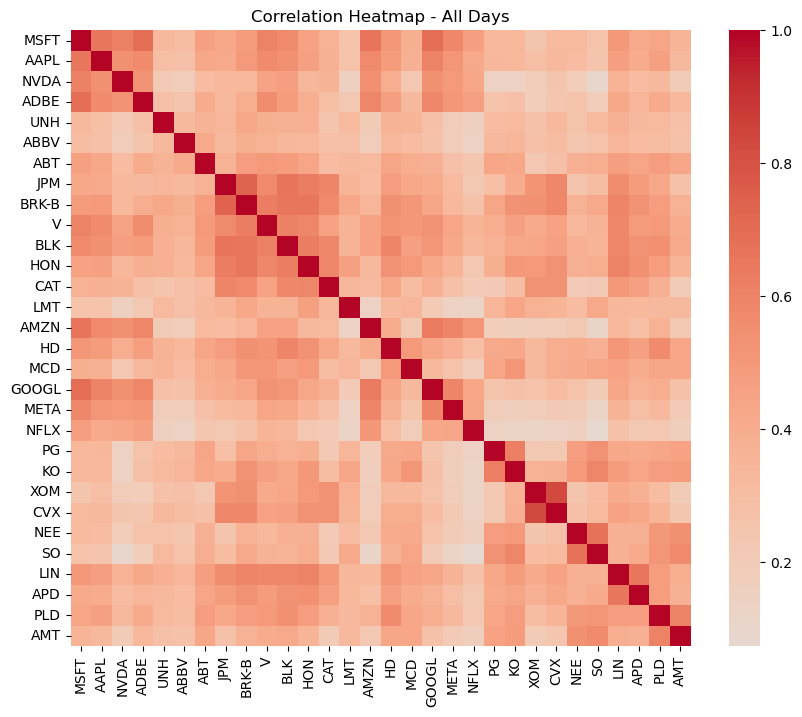

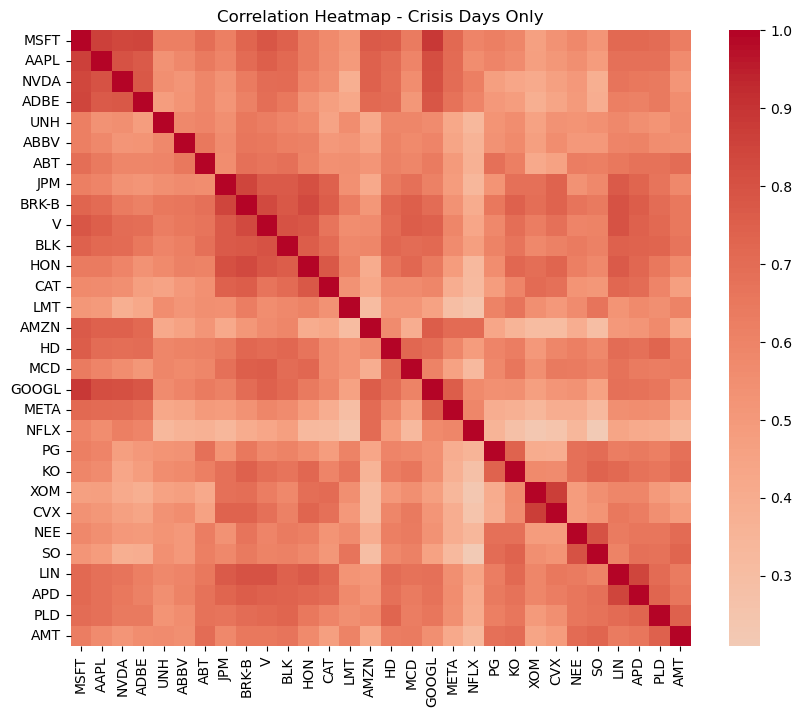

In [139]:
import seaborn as sns

corr_all = data[tickers].corr()
corr_crisis = data.loc[data["regime"] == "crisis", tickers].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_all, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - All Days")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_crisis, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Crisis Days Only")
plt.show()

            EW_portfolio_return    VIX  regime
Date                                          
2020-03-16            -0.133444  82.69  crisis
2020-03-12            -0.097752  75.47  crisis
2020-03-09            -0.080172  54.46  crisis
2025-04-04            -0.057881  45.31  crisis
2020-06-11            -0.057802  40.79  crisis
2020-03-18            -0.051089  76.45  crisis
2020-04-01            -0.048232  57.06  crisis
2020-02-27            -0.046274  39.16  crisis
2020-03-20            -0.045930  66.04  crisis
2020-03-11            -0.045474  53.90  crisis
2022-09-13            -0.045157  27.27  crisis
2018-02-05            -0.042503  37.32  crisis
2022-06-13            -0.038826  34.02  crisis
2018-02-08            -0.038729  33.46  crisis
2022-04-29            -0.036593  33.40  crisis


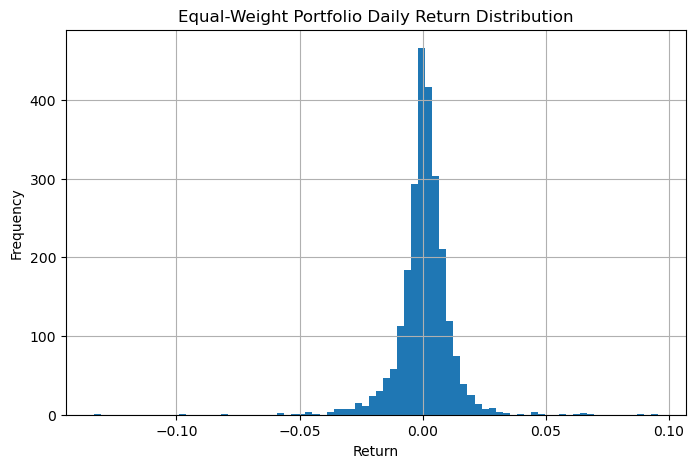

In [140]:
ew_ret = returns.mean(axis=1)
tail_table = pd.DataFrame({
    "EW_portfolio_return": ew_ret,
    "VIX": data["VIX"],
    "regime": data["regime"]
}).sort_values("EW_portfolio_return")

print(tail_table.head(15))

tail_table["EW_portfolio_return"].hist(bins=80, figsize=(8,5))
plt.title("Equal-Weight Portfolio Daily Return Distribution")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()